# Classifying Fashion Products: CNN vs. Random Forest on Fashion-MNIST

Project report notebook: DLBAIPCV01, Task 2.
Reproduces the best Random Forest classifier from Xiao et al. (2017) and
compares it against a CNN implemented in PyTorch, on the official
Fashion-MNIST train/test split (60,000 / 10,000 images).

All library code lives in the fmnist package: this notebook orchestrates
training, evaluation, and result presentation. Experiments are tracked
with MLflow. Seeds are fixed for reproducibility.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Description and Exploratory Data Analysis

Fashion-MNIST (Xiao et al., 2017) contains 70,000 grayscale 28×28 images
of Zalando fashion products in 10 classes, split into 60,000 training and
10,000 test images. This section verifies the dataset's basic properties
programmatically and explores its visual structure.

In [43]:
from fmnist.data import get_dataset, get_numpy_data
X_train, y_train, X_test, y_test = get_numpy_data()

### 1.1 Basic properties

Shapes, value range, and label set: computed from the loaded arrays
rather than quoted from the paper.

In [44]:
print(f"X_train -> shape:{X_train.shape}, ndim:{X_train.ndim}")
print(f"y_train -> shape:{y_train.shape}, ndim:{y_train.ndim}")
print(f"X_test -> shape:{X_test.shape}, ndim:{X_test.ndim}")
print(f"y_test -> shape:{y_test.shape}, ndim:{y_test.ndim}")

X_train -> shape:(60000, 784), ndim:2
y_train -> shape:(60000,), ndim:1
X_test -> shape:(10000, 784), ndim:2
y_test -> shape:(10000,), ndim:1


In [45]:
print(f"X_train -> dtype: {X_train.dtype}, min:{X_train.min()}, max:{X_train.max()}, mean: {round(X_train.mean(), 2)}")
print(f"y_train -> dtype: {y_train.dtype}, min:{y_train.min()}, max:{y_train.max()}, mean:{round(y_train.mean(), 2)}")
print(f"X_test -> dtype: {X_test.dtype}, min:{X_test.min()}, max:{X_test.max()}, mean:{round(X_test.mean(), 2)}")
print(f"y_test -> dtype: {y_test.dtype}, min:{y_test.min()}, max:{y_test.max()}, mean:{round(y_test.mean(), 2)}")

X_train -> dtype: uint8, min:0, max:255, mean: 72.94
y_train -> dtype: int64, min:0, max:9, mean:4.5
X_test -> dtype: uint8, min:0, max:255, mean:73.15
y_test -> dtype: int64, min:0, max:9, mean:4.5


In [46]:
labels = np.unique(y_train)
print(f"label set: {labels}, n_classes: {len(labels)}")

label set: [0 1 2 3 4 5 6 7 8 9], n_classes: 10


### 1.2 Sample images per class

Eight training examples per class, one row per class. Fixed examples
(first eight of each class) so the figure is reproducible across runs.

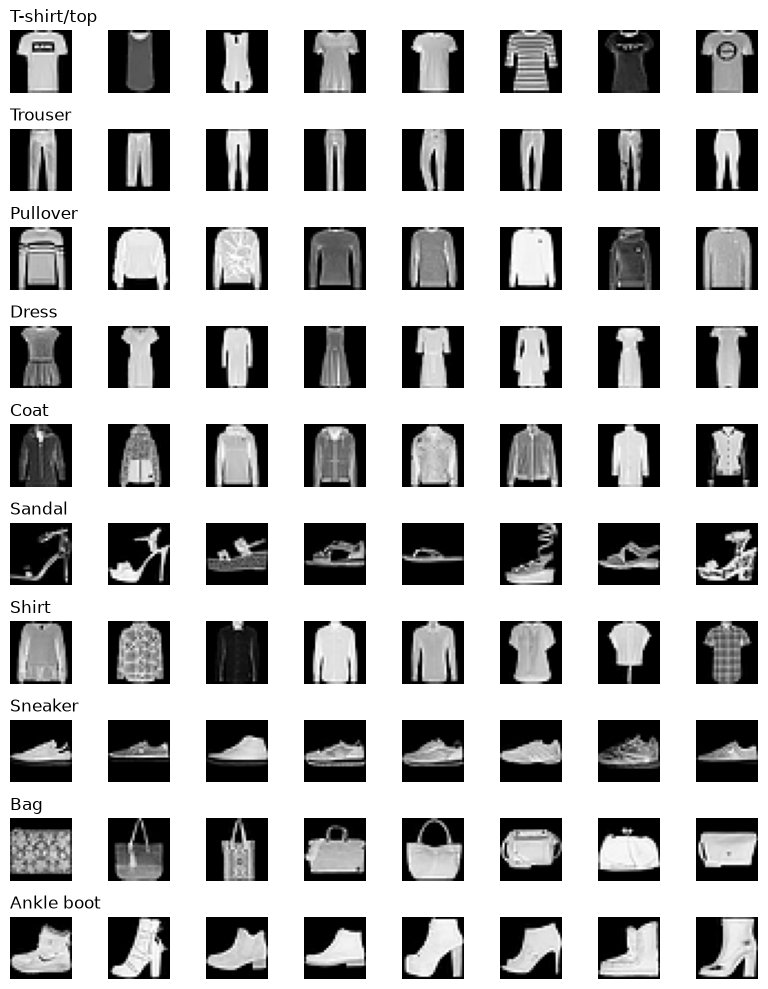

In [47]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
fig, axs = plt.subplots(10, 8, figsize=(8,10))
for c in range(10):
    idxs = np.where(y_train == c)[0][:8]
    for j, idx in enumerate(idxs):
        axs[c, j].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axs[c, j].axis("off")
    axs[c, 0].set_title(CLASS_NAMES[c], loc="left")    
plt.tight_layout()
    

### 1.3 Class balance

Both splits are perfectly balanced: 6,000 training and 1,000 test images
per class. Accuracy is therefore a meaningful headline metric and no
resampling is needed.

In [48]:
df = pd.DataFrame(data=np.unique(y_train, return_counts=True)[1], index=CLASS_NAMES, columns=["Counts"])
df

,Counts
T-shirt/top,6000
Trouser,6000
Pullover,6000
Dress,6000
Coat,6000
Sandal,6000
Shirt,6000
Sneaker,6000
Bag,6000
Ankle boot,6000


In [49]:
df = pd.DataFrame(data=np.unique(y_test, return_counts=True)[1], index=CLASS_NAMES, columns=["Counts"])
df

,Counts
T-shirt/top,1000
Trouser,1000
Pullover,1000
Dress,1000
Coat,1000
Sandal,1000
Shirt,1000
Sneaker,1000
Bag,1000
Ankle boot,1000


### 1.4 Mean image per class

Pixel-wise average of all training images per class. Distinct silhouettes
(e.g., Trouser, Bag) suggest easy separation, while T-shirt/top, Pullover,
Coat, and Shirt produce nearly identical means: anticipating where both
classifiers should struggle.

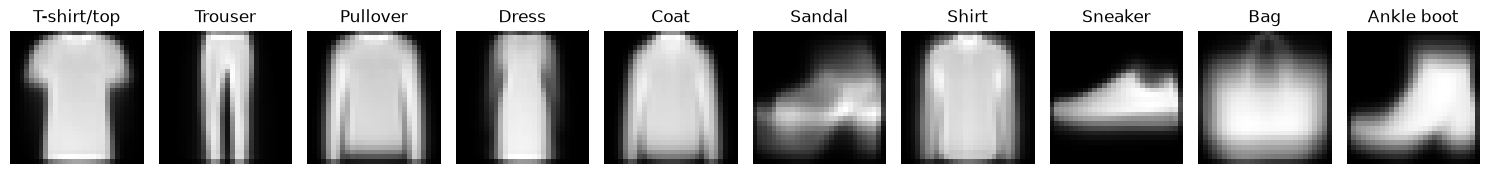

In [50]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
fig, axs = plt.subplots(1, 10, figsize=(15,2))
for c in range(10):
    mean_img = X_train[y_train == c].mean(axis=0)
    axs[c].imshow(mean_img.reshape(28, 28), cmap="gray")
    axs[c].axis("off")
    axs[c].set_title(CLASS_NAMES[c])
plt.tight_layout()

### 1.5 Pixel intensity distribution

Most pixels are background (value 0). CNN inputs are scaled to [0, 1]:
the Random Forest uses raw 8-bit values, since tree-based models are
invariant to monotonic scaling.

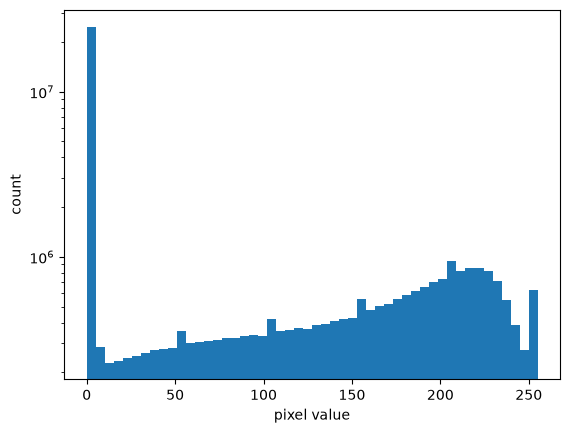

In [51]:
values = X_train.ravel()
plt.hist(values, bins=50)
plt.xlabel("pixel value")
plt.ylabel("count")
plt.yscale("log")